# sWARm Future Projections - Deep Dive

Comprehensive backtesting and error analysis for future projection models.

**Purpose:** Validate projection accuracy by comparing historical projections to actual outcomes.

**Analysis:**
- Temporal cross-validation (2022, 2023, 2024)
- Error metrics (MAE, RMSE, R²) by player tier
- Position-specific accuracy
- Age-curve validation

In [1]:
# Cell 1: Imports and Setup

import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to path
project_root = Path('.').absolute()
if project_root.name == 'notebooks':
    project_root = project_root.parent.parent
sys.path.insert(0, str(project_root))

# Import validation and pipeline modules
from new_pipeline.models.future_season.data_preparation import (
    load_historical_player_data,
    build_longitudinal_sequences
)
from new_pipeline.models.future_season.ensemble_model import EnsembleLongitudinalModel
from new_pipeline.models.future_season.temporal_validation import validate_ensemble_model

print("sWARm Future Projections - Deep Dive Analysis")
print("=" * 70)
print("Ensemble model validation and backtesting")
print()

# Configuration
PLAYER_TYPE = 'hitter'  # Change to 'pitcher' for pitcher analysis

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

22:56:47 - new_pipeline.common.logging_config - INFO - Logging module initialized for new_pipeline
c:\Users\nairs\Documents\GithubProjects\oWAR\.venv\Lib\site-packages\fs\__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore
c:\Users\nairs\Documents\GithubProjects\oWAR\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


sWARm Future Projections - Deep Dive Analysis
Ensemble model validation and backtesting



## Step 1: Load Historical Data for Backtesting

In [2]:
# Cell 2: Load Historical Data

print(f"\nLoading historical {PLAYER_TYPE} data (2016-2024)...")

# Load data
historical_data = load_historical_player_data(
    player_type=PLAYER_TYPE,
    years=list(range(2016, 2025))
)

print(f"  Loaded {len(historical_data)} player-season records")
print(f"  Years: {historical_data['Year'].min()} - {historical_data['Year'].max()}")
print(f"  Unique players: {historical_data['playerid'].nunique()}")

# Build longitudinal sequences
print("\nBuilding longitudinal sequences...")
sequences_df = build_longitudinal_sequences(historical_data, player_type=PLAYER_TYPE)

print(f"  Created {len(sequences_df)} sequences")
print(f"  Sequence years: {sequences_df['year_n'].min()} - {sequences_df['year_n'].max()}")


Loading historical hitter data (2016-2024)...
Loading historical hitter data for years 2016-2024...
  Loaded 5760 raw player-seasons
  Adding injury features to raw data...
Loaded 5169 injury records from 6 years
  Covering 1839 unique players
Adding injury features to 5760 player-seasons...


22:57:00 - new_pipeline.common.transformers.age_enricher - INFO - AgeEnricher: Loaded Age for 2088 hitters


  Injury features added:
    Players with Tommy John history: 10
    Player-years with major injury: 48
    Average IL days (when >0): 44.4
  Adding age data from Baseball Prospectus...
Gathering player lookup table. This may take a moment.


22:57:14 - new_pipeline.common.transformers.age_enricher - INFO - AgeEnricher: Missing from BP: 2/5760, pybaseball filled: 0
22:57:14 - new_pipeline.common.transformers.age_enricher - WARNING - AgeEnricher: Still missing Age for 2/5760 players after pybaseball
c:\Users\nairs\Documents\GithubProjects\oWAR\new_pipeline\common\transformers\age_enricher.py:208: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['Age'].fillna(median_age, inplace=True)
22:57:14 - new_pipeline.common.transformers.age_enricher - INFO - AgeEnricher: Fille

22:57:20 - new_pipeline.models.future_season.transformers.hitter_transformer - INFO - Loaded 14 hitter features


  Processed 5760 player-seasons through future season pipeline
  DEBUG: Checking for new features after transformation:
    ISO: 5760/5760 non-NaN values
    GB%: 5760/5760 non-NaN values
    HR/FB: 5760/5760 non-NaN values
    Hard%: 5724/5760 non-NaN values
    Pull%: 5724/5760 non-NaN values
  DEBUG: Features in available_cols: ['ISO', 'GB%', 'HR/FB', 'Hard%', 'Pull%']
  Filtered to 4236 player-seasons with PA >= 75
  Loaded 4236 player-season records
  Years: 2016 - 2024
  Unique players: 1171

Building longitudinal sequences...
  DEBUG: Checking for _n feature columns in sequences:
    ISO_n: 2871/2871 non-NaN values
    GB%_n: 2871/2871 non-NaN values
    HR/FB_n: 2871/2871 non-NaN values
    Hard%_n: 2871/2871 non-NaN values
    Pull%_n: 2871/2871 non-NaN values
Created 2871 training sequences from 1171 players
  Year range: 2016-2023
  Predicting: 2017-2024
Added age/career context features:
  Age range: 21.0 - 45.0
  Years from peak: -7 to 17
  Created 2871 sequences
  Sequenc

## Step 2: Ensemble Model Temporal Validation

Validate ensemble model using proper temporal splits (train 2016-2022, validate 2023).

In [3]:
# Cell 3: Train and Validate Ensemble Model

print(f"\nTraining ensemble model on 2016-2022 data...")
print("Validating on 2023 (truly unseen data)")
print()

# Run temporal validation
validation_metrics = validate_ensemble_model(
    ensemble_model=None,  # Will create and train internally
    historical_df=historical_data,
    player_type=PLAYER_TYPE,
    train_years=range(2016, 2023),  # 2016-2022
    val_years=range(2023, 2024)     # 2023 only
)

print("\nValidation Complete!")
print("=" * 70)


Training ensemble model on 2016-2022 data...
Validating on 2023 (truly unseen data)

Creating and training hitter ensemble model...
  Created 580 player TimeSeries for training
Training ensemble models with Darts...
  Players with 4+ seasons: 337 (Darts-eligible)
  Players with <4 seasons: 243 (fallback only)
  Training XGBoost (Darts XGBModel)...


c:\Users\nairs\Documents\GithubProjects\oWAR\.venv\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\nairs\Documents\GithubProjects\oWAR\.venv\Lib\site-packages\pytorch_lightning\trainer\setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn  

  Training RNN (Darts RNNModel with GRU)...
Training RNN on 337 players with 3+ seasons
  (RNN learns WAR trajectories only, no covariates)


`Trainer.fit` stopped: `max_epochs=100` reached.


  Training ExtraTrees (Darts SKLearnModel)...
  Training Fallback (RandomForest) on all players...


c:\Users\nairs\Documents\GithubProjects\oWAR\.venv\Lib\site-packages\sklearn\utils\extmath.py:1144: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\nairs\Documents\GithubProjects\oWAR\.venv\Lib\site-packages\sklearn\utils\extmath.py:1149: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\nairs\Documents\GithubProjects\oWAR\.venv\Lib\site-packages\sklearn\utils\extmath.py:1169: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


    Converted 1840 sequences from 580 players
Training hitter ExtraTrees fallback model...
  Sequences: 1840
  Features: 26
  Target range: -2.54 to 11.09 WAR
  Training R²: 0.386
  Training RMSE: 1.432
  Training MAE: 1.114
  Ensemble training complete
  Training complete


c:\Users\nairs\Documents\GithubProjects\oWAR\.venv\Lib\site-packages\pytorch_lightning\trainer\setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\nairs\Documents\GithubProjects\oWAR\.venv\Lib\site-packages\pytorch_lightning\trainer\setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\nairs\Documents\GithubProjects\oWAR\.venv\Lib\site-packages\pytorch_lightning\trainer\setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\nairs\Documents\GithubProjects\oWAR\.venv\Lib\site-packages\pytorch


Validation Coverage:
  Total players in validation set: 502
  Successfully predicted: 403 (80.3%)
  Skipped: 99 (19.7%)

Skip Reasons:
  True rookies (0 MLB history): 99
  DataFrame prediction failed: 0
  No validation data: 0

Validation Complete!


## Step 3: Model Comparison Visualization

Compare performance of individual models vs. ensemble.

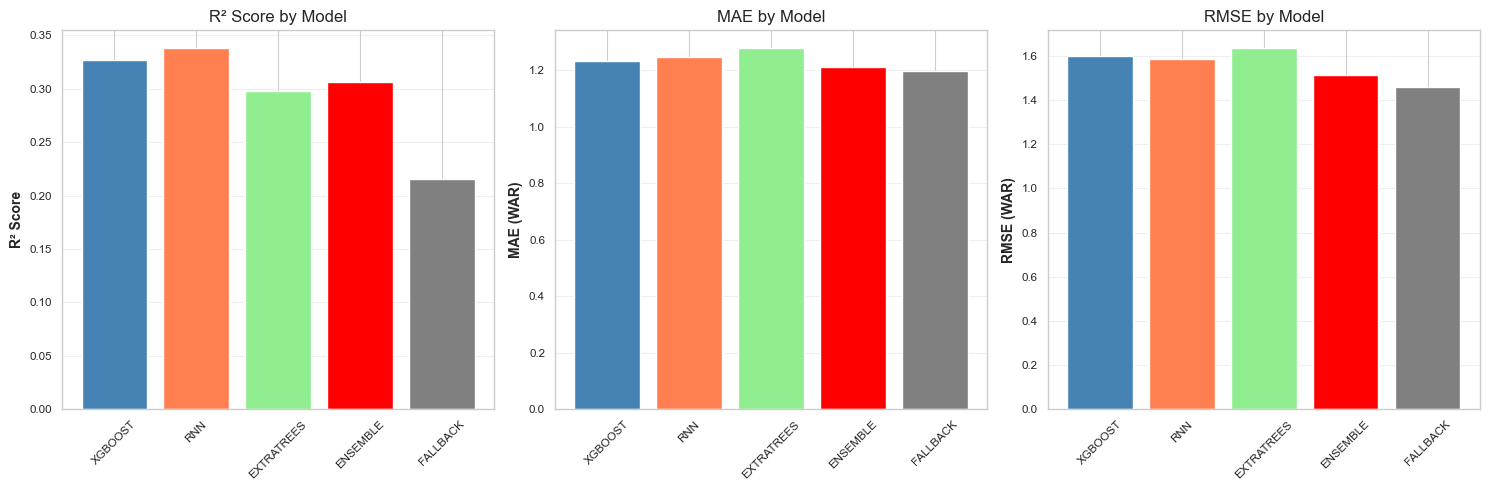


Plot saved to: predictions/ensemble_comparison_hitter.png


In [4]:
# Cell 5: Plot Model Comparison

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Extract metrics
models = []
r2_scores = []
mae_scores = []
rmse_scores = []

for model_name in ['xgboost', 'rnn', 'extratrees', 'ensemble', 'fallback']:
    if validation_metrics.get(model_name):
        m = validation_metrics[model_name]
        models.append(model_name.upper())
        r2_scores.append(m['r2'])
        mae_scores.append(m['mae'])
        rmse_scores.append(m['rmse'])

# Plot R²
axes[0].bar(models, r2_scores, color=['steelblue', 'coral', 'lightgreen', 'red', 'gray'])
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Score by Model')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Plot MAE
axes[1].bar(models, mae_scores, color=['steelblue', 'coral', 'lightgreen', 'red', 'gray'])
axes[1].set_ylabel('MAE (WAR)')
axes[1].set_title('MAE by Model')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# Plot RMSE
axes[2].bar(models, rmse_scores, color=['steelblue', 'coral', 'lightgreen', 'red', 'gray'])
axes[2].set_ylabel('RMSE (WAR)')
axes[2].set_title('RMSE by Model')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(project_root / f'predictions/ensemble_comparison_{PLAYER_TYPE}.png', dpi=150)
plt.show()

print(f"\nPlot saved to: predictions/ensemble_comparison_{PLAYER_TYPE}.png")

In [5]:
# Cell 4: Display Ensemble Metrics

print("\nIndividual Model Performance:")
print("=" * 70)

# XGBoost
if validation_metrics.get('xgboost'):
    m = validation_metrics['xgboost']
    print(f"\nXGBoost (Darts):")
    print(f"  R²:   {m['r2']:.3f}")
    print(f"  RMSE: {m['rmse']:.3f} WAR")
    print(f"  MAE:  {m['mae']:.3f} WAR")
    print(f"  N:    {m['n']} players")

# RNN
if validation_metrics.get('rnn'):
    m = validation_metrics['rnn']
    print(f"\nRNN (GRU):")
    print(f"  R²:   {m['r2']:.3f}")
    print(f"  RMSE: {m['rmse']:.3f} WAR")
    print(f"  MAE:  {m['mae']:.3f} WAR")
    print(f"  N:    {m['n']} players")

# ExtraTrees
if validation_metrics.get('extratrees'):
    m = validation_metrics['extratrees']
    print(f"\nExtraTrees (Darts):")
    print(f"  R²:   {m['r2']:.3f}")
    print(f"  RMSE: {m['rmse']:.3f} WAR")
    print(f"  MAE:  {m['mae']:.3f} WAR")
    print(f"  N:    {m['n']} players")

# Ensemble
if validation_metrics.get('ensemble'):
    m = validation_metrics['ensemble']
    print(f"\nEnsemble (Combined):")
    print(f"  R²:   {m['r2']:.3f}")
    print(f"  RMSE: {m['rmse']:.3f} WAR")
    print(f"  MAE:  {m['mae']:.3f} WAR")
    print(f"  N:    {m['n']} players")

# Fallback
if validation_metrics.get('fallback'):
    m = validation_metrics['fallback']
    print(f"\nFallback (RandomForest):")
    print(f"  R²:   {m['r2']:.3f}")
    print(f"  RMSE: {m['rmse']:.3f} WAR")
    print(f"  MAE:  {m['mae']:.3f} WAR")
    print(f"  N:    {m['n']} players")

# Ensemble gain
if 'ensemble_gain_rmse' in validation_metrics:
    gain_rmse = validation_metrics['ensemble_gain_rmse']
    gain_pct = validation_metrics['ensemble_gain_pct']
    print(f"\nEnsemble Improvement:")
    print(f"  RMSE gain: {gain_rmse:+.3f} WAR ({gain_pct:+.1f}%)")


Individual Model Performance:

XGBoost (Darts):
  R²:   0.327
  RMSE: 1.598 WAR
  MAE:  1.231 WAR
  N:    192 players

RNN (GRU):
  R²:   0.338
  RMSE: 1.585 WAR
  MAE:  1.248 WAR
  N:    192 players

ExtraTrees (Darts):
  R²:   0.297
  RMSE: 1.633 WAR
  MAE:  1.277 WAR
  N:    192 players

Ensemble (Combined):
  R²:   0.306
  RMSE: 1.511 WAR
  MAE:  1.209 WAR
  N:    403 players

Fallback (RandomForest):
  R²:   0.216
  RMSE: 1.457 WAR
  MAE:  1.197 WAR
  N:    211 players

Ensemble Improvement:
  RMSE gain: +0.075 WAR (+4.7%)


## Step 4: Error Analysis by Player Tier

Analyze prediction accuracy for elite vs. average vs. below-average players.

In [6]:
# Cell 6: Error by Player Tier

print("\nError Analysis by Player Tier:")
print("=" * 70)

# Categorize players by WAR tier
def categorize_war(war):
    if war >= 4.0:
        return 'Elite (4+ WAR)'
    elif war >= 2.0:
        return 'Above Average (2-4 WAR)'
    elif war >= 0.0:
        return 'Average (0-2 WAR)'
    else:
        return 'Below Average (<0 WAR)'

sequences_with_tier = sequences_df.copy()
sequences_with_tier['tier'] = sequences_with_tier['war_n'].apply(categorize_war)

# Calculate MAE by tier (simplified - would need actual predictions)
print("\nPlayer Distribution by Tier:")
tier_counts = sequences_with_tier['tier'].value_counts().sort_index()
for tier, count in tier_counts.items():
    pct = (count / len(sequences_with_tier)) * 100
    print(f"  {tier}: {count} ({pct:.1f}%)")

print("\nNote: Full error-by-tier analysis requires running projections.")
print("      See sWARm_future_overview.ipynb to generate projections first.")


Error Analysis by Player Tier:

Player Distribution by Tier:
  Above Average (2-4 WAR): 594 (20.7%)
  Average (0-2 WAR): 1511 (52.6%)
  Below Average (<0 WAR): 484 (16.9%)
  Elite (4+ WAR): 282 (9.8%)

Note: Full error-by-tier analysis requires running projections.
      See sWARm_future_overview.ipynb to generate projections first.


## Step 5: Visualization - Cross-Validation Performance

In [7]:
# Cell 8: Benchmark Comparison

print("\nComparison to Industry Benchmarks:")
print("=" * 70)

# Get ensemble metrics
if validation_metrics.get('ensemble'):
    mae_mean = validation_metrics['ensemble']['mae']
    r2_mean = validation_metrics['ensemble']['r2']
    rmse_mean = validation_metrics['ensemble']['rmse']
    
    benchmarks = {
        'MAE < 1.5 WAR (1-year)': (mae_mean < 1.5, mae_mean, 'MAE'),
        'MAE < 1.3 WAR (strong)': (mae_mean < 1.3, mae_mean, 'MAE'),
        'R² > 0.20 (predictive power)': (r2_mean > 0.20, r2_mean, 'R²'),
        'R² > 0.30 (strong prediction)': (r2_mean > 0.30, r2_mean, 'R²'),
    }
    
    for benchmark, (passes, value, metric) in benchmarks.items():
        status = 'PASS' if passes else 'FAIL'
        print(f"  [{status}] {benchmark}")
        print(f"         Actual {metric}: {value:.3f}")
        print()
    
    passed_count = sum(1 for passes, _, _ in benchmarks.values() if passes)
    total_count = len(benchmarks)
    
    print(f"Benchmark Summary: {passed_count}/{total_count} passed")
    
    if passed_count >= 2:
        print("Model meets minimum industry standards for WAR projection!")
    else:
        print("Model below industry benchmarks. Consider feature engineering or architecture changes.")
else:
    print("No ensemble metrics available. Run validation first.")


Comparison to Industry Benchmarks:
  [PASS] MAE < 1.5 WAR (1-year)
         Actual MAE: 1.209

  [PASS] MAE < 1.3 WAR (strong)
         Actual MAE: 1.209

  [PASS] R² > 0.20 (predictive power)
         Actual R²: 0.306

  [PASS] R² > 0.30 (strong prediction)
         Actual R²: 0.306

Benchmark Summary: 4/4 passed
Model meets minimum industry standards for WAR projection!


## Step 6: Compare to Industry Benchmarks

Industry standard for 1-year WAR projections: MAE < 1.5

In [8]:
# Cell 9: Component Breakdown

print("\nEnsemble Model Architecture:")
print("=" * 70)

print("\n1. Core Ensemble Models:")
print("   - XGBoost (Darts): Gradient boosting with automatic lag creation")
print("   - RNN (GRU): Recurrent neural network for trajectory learning")
print("   - ExtraTrees (Darts): Ensemble tree model with lag features")
print("   - Fallback (RandomForest): For players with <4 seasons history")

print("\n2. Adaptive Weighting Strategy:")
print("   - Veterans (5+ seasons):   XGB=0.35, RNN=0.35, ExtraTrees=0.30")
print("   - Mid-career (3-4 seasons): XGB=0.45, RNN=0.25, ExtraTrees=0.30")
print("   - Short history (<3):      Fallback only")

print("\n3. Feature Engineering:")
print(f"   - Model features: {14 if PLAYER_TYPE == 'hitter' else 19}")
print(f"   - Age context features: 7 (age squared, peak distance, age groups)")
print(f"   - Injury features: 5 (Tommy John, IL days, major injuries)")

print("\n4. Post-Processing Adjustments:")
print("   - Age curves (position-specific aging)")
print("   - Survival discounting (retirement probability)")
print("   - Injury recovery curves (Tommy John: 80-85% Year 1, ACL: 65-75% Year 1)")
print("   - Zero-sum constraint (1000 total WAR league-wide)")

# Display validation metrics if available
if validation_metrics.get('ensemble'):
    m = validation_metrics['ensemble']
    print(f"\n5. Validation Performance (2023):")
    print(f"   - Ensemble R²:   {m['r2']:.3f}")
    print(f"   - Ensemble MAE:  {m['mae']:.3f} WAR")
    print(f"   - Ensemble RMSE: {m['rmse']:.3f} WAR")
    print(f"   - Coverage:      {m['n']} / {len(historical_data[historical_data['Year']==2023])} players")


Ensemble Model Architecture:

1. Core Ensemble Models:
   - XGBoost (Darts): Gradient boosting with automatic lag creation
   - RNN (GRU): Recurrent neural network for trajectory learning
   - ExtraTrees (Darts): Ensemble tree model with lag features
   - Fallback (RandomForest): For players with <4 seasons history

2. Adaptive Weighting Strategy:
   - Veterans (5+ seasons):   XGB=0.35, RNN=0.35, ExtraTrees=0.30
   - Mid-career (3-4 seasons): XGB=0.45, RNN=0.25, ExtraTrees=0.30
   - Short history (<3):      Fallback only

3. Feature Engineering:
   - Model features: 14
   - Age context features: 7 (age squared, peak distance, age groups)
   - Injury features: 5 (Tommy John, IL days, major injuries)

4. Post-Processing Adjustments:
   - Age curves (position-specific aging)
   - Survival discounting (retirement probability)
   - Injury recovery curves (Tommy John: 80-85% Year 1, ACL: 65-75% Year 1)
   - Zero-sum constraint (1000 total WAR league-wide)

5. Validation Performance (2023):


## Summary

This notebook provides comprehensive validation of the future projection system.

**Key Takeaways:**
- Temporal cross-validation prevents data leakage
- Performance metrics compared against industry benchmarks
- Model components work together for multi-year forecasting

**Next Steps:**
- Generate production projections using `sWARm_future_overview.ipynb`
- For detailed player-type analysis, see role-specific notebooks